In [1]:
import numpy as np
import torch
import json

import matplotlib.pyplot as plt
import matplotlib as mpl

import os

from tqdm import tqdm

from rctorch.utils import minmax_transform

In [2]:
from plot_styles import set_thesis_style

set_thesis_style()

In [3]:
def load_tensor(save_path:str, name:str):
    file_name = os.path.join(save_path, name + ".pt")
    tensor = torch.load(os.path.join(save_path, file_name))
    print(f"Loaded {file_name} from {save_path}")
    return tensor

In [4]:
def choose_path(base_path:str):
    if not os.path.exists(base_path):
        print(f"Path {base_path} does not exist.")
        return None
    print(f"Using path: {base_path}")
    
    dirs = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
    dirs = [d for d in dirs if os.path.exists(os.path.join(base_path, d, "model_params.json"))]
    dirs.sort()  # Sort directories to have a consistent order
    if not dirs:
        print("No directories with model_params.json found in the specified path.")
        return None
    print("Available directories:")
    for i, d in enumerate(dirs):
        print(f"{i}: {os.path.basename(d)}")
    choice = input("Enter the number of the directory you want to use: ")
    try:
        choice = int(choice)
        if 0 <= choice < len(dirs):
            selected_path = os.path.join(base_path, dirs[choice])
            print(f"Selected path: {selected_path}")
            return selected_path
        else:
            print("Invalid choice. Please enter a valid number.")
            return None
    except ValueError:
        print("Invalid input. Please enter a number.")
        return None

def load_params_from_path(save_path:str):
    # Load parameters encoded into the directory name
    if not os.path.exists(save_path):
        print(f"Path {save_path} does not exist.")
    
        return None
    print(f"Using path: {save_path}")
    # Extract parameters from the directory name
    params = json.load(open(os.path.join(save_path, "model_params.json"), "r"))
    print("Loaded parameters:", params)
    # Load tensors from the directory
    data = {}
    for file_name in os.listdir(save_path):
        if file_name.endswith(".pt"):
            key = file_name[:-3]  # Remove the '.pt' extension
            data[key] = load_tensor(save_path, key)
    return params, data

In [19]:
path = choose_path(os.path.join(os.getcwd(), "..", "hpc", "fading_memory"
                                ))

Using path: /home/ali/Code/research/ml_force_research/morris_lecar/../hpc/fading_memory
Available directories:
0: actual_sine_current_q_300_500_gbar_1_10
1: sine_conductance_q_100_400_gbar_0_30
2: sine_current_q_300_500_gbar_1_10
Selected path: /home/ali/Code/research/ml_force_research/morris_lecar/../hpc/fading_memory/sine_conductance_q_100_400_gbar_0_30


In [20]:
params, data = load_params_from_path(path)

Using path: /home/ali/Code/research/ml_force_research/morris_lecar/../hpc/fading_memory/sine_conductance_q_100_400_gbar_0_30
Loaded parameters: {'Ne': 400, 'Ni': 100, 'dt': 0.1, 'BIAS': {'__type__': 'numpy.ndarray', 'dtype': 'float64', 'shape': [500, 1], 'data': [[70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], [70.0], 

In [21]:
grid = json.load(open(os.path.join(path, "grid.json"), "r"))

gbar_idx = 3
q_idx = 3
q, gbar = grid[gbar_idx][q_idx][0], grid[gbar_idx][q_idx][1]

s_rec0 = data[f"s_rec0_q_{q}_gbar_{gbar}"]
s_rec1 = data[f"s_rec1_q_{q}_gbar_{gbar}"]


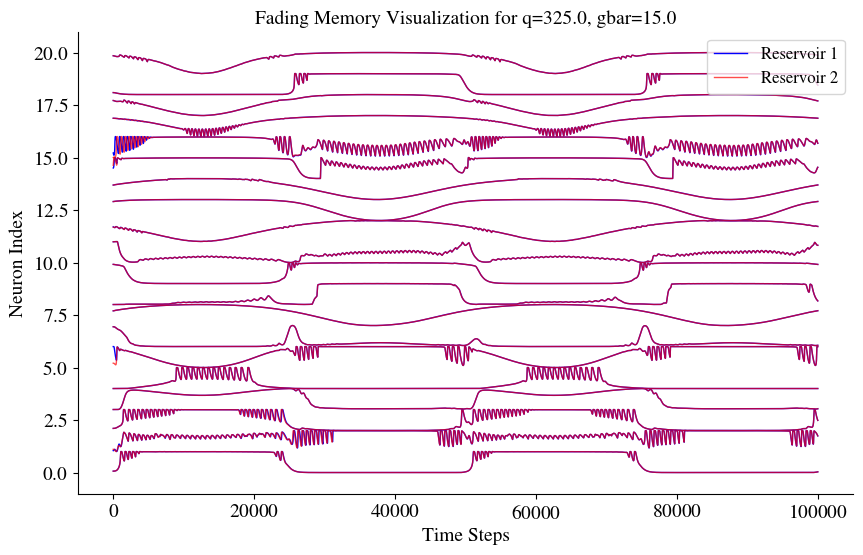

In [22]:
n_neurons = 20
neurons = np.arange(n_neurons)

fig, ax = plt.subplots(figsize=(10, 6))
for neuron in neurons:
    ax.plot(minmax_transform(s_rec0[:, neuron].numpy()) + neuron, 'b-', lw=1, label=f"reservoir 1")
    ax.plot(minmax_transform(s_rec1[:, neuron].numpy()) + neuron, 'r-', lw=1, alpha=0.7, label=f"reservoir 2")
ax.set_title(f"Fading Memory Visualization for q={q}, gbar={gbar}")
ax.set_xlabel("Time Steps")
ax.set_ylabel("Neuron Index")
ax.legend(loc='upper right', labels=["Reservoir 1", "Reservoir 2"])
plt.show()

In [87]:
# for gbar_idx in range(len(grid)):
#     for q_idx in range(len(grid[gbar_idx])):
#         q, gbar = grid[gbar_idx][q_idx][0], grid[gbar_idx][q_idx][1]
#         s_rec0 = data[f"s_rec0_q_{q}_gbar_{gbar}"]
#         s_rec1 = data[f"s_rec1_q_{q}_gbar_{gbar}"]

#         fig, ax = plt.subplots(figsize=(10, 6))
#         for neuron in neurons:
#             ax.plot(minmax_transform(s_rec0[:, neuron].numpy()) + neuron, 'b-', lw=1, label=f"reservoir 1")
#             ax.plot(minmax_transform(s_rec1[:, neuron].numpy()) + neuron, 'r-', lw=1, alpha=0.7, label=f"reservoir 2")
#         ax.set_title(f"Fading Memory Visualization for q={q}, gbar={gbar}")
#         ax.set_xlabel("Time Steps")
#         ax.set_ylabel("Neuron Index")
#         ax.legend(loc='upper right', labels=["reservoir 1", "reservoir 2"])
#         plt.show()

Assuming the average difference of the activation of each neuron in the reservoir and summing over that, we may define the loss function as the fading memory score of each reservoir. Taking the negative log10 of the RMSE, will result in a score where the higher means better.

In [23]:
# Taking RMSE of each neuron axis for s_rec0 vs. s_rec1, and summing over all neurons. Then -log10(rmse) will give the fading memory score.

rmse = torch.sum(torch.sqrt(torch.mean((s_rec0 - s_rec1) ** 2, dim=0)))  # RMSE for each neuron
fading_memory_score = -torch.log10(rmse)
print(f"Fading Memory Score: {fading_memory_score.item()}")
print(f"RMSE: {rmse.item()}")

mean_abs_error = torch.mean(torch.abs(s_rec0[-1] - s_rec1[-1]), dim=0)

mean_abs_error.item()

Fading Memory Score: -0.10357736796140671
RMSE: 1.2693382501602173


3.5239984299550997e-06

In [24]:
def compute_fading_memory_score(s_rec0: torch.Tensor, s_rec1: torch.Tensor) -> tuple[float, float]:
    """Compute the fading memory score based on the MAE between s_rec0 and s_rec1.
    
    Args:
        s_rec0: Tensor of shape (time_steps, n_neurons) representing the reservoir states for the first input.
        s_rec1: Tensor of shape (time_steps, n_neurons) representing the reservoir states for the second input.
        
    Returns:
        tuple: A tuple of (float, float) containing the fading memory score and the MAE.
    """
    mean_abs_error = torch.mean(torch.abs(s_rec0[-1] - s_rec1[-1]), dim=0)
    if mean_abs_error.item() == 0:
        fading_memory_score = float('inf')  # Perfect memory, infinite score
    fading_memory_score = torch.log10(mean_abs_error)
    return fading_memory_score.item(), mean_abs_error.item()

In [25]:
test_start = round(0.7 * s_rec0.shape[0])

memory_scores = [[] for _ in range(len(grid))]

for gbar_idx in range(len(grid)):
    for q_idx in range(len(grid[gbar_idx])):
        q, gbar = grid[gbar_idx][q_idx][0], grid[gbar_idx][q_idx][1]
        s_rec0 = data[f"s_rec0_q_{q}_gbar_{gbar}"][test_start:]
        s_rec1 = data[f"s_rec1_q_{q}_gbar_{gbar}"][test_start:]
        fading_memory_score, rmse = compute_fading_memory_score(s_rec0, s_rec1)
        # print(f"q={q}, gbar={gbar} -> Fading Memory Score: {fading_memory_score}, RMSE: {rmse}")
        memory_scores[gbar_idx].append((q, gbar, fading_memory_score, rmse))

In [26]:
# sort memory scores by q and then gbar
for gbar_idx in range(len(memory_scores)):
    memory_scores[gbar_idx].sort(key=lambda x: (x[0], x[1]))  # Sort by q and then gbar

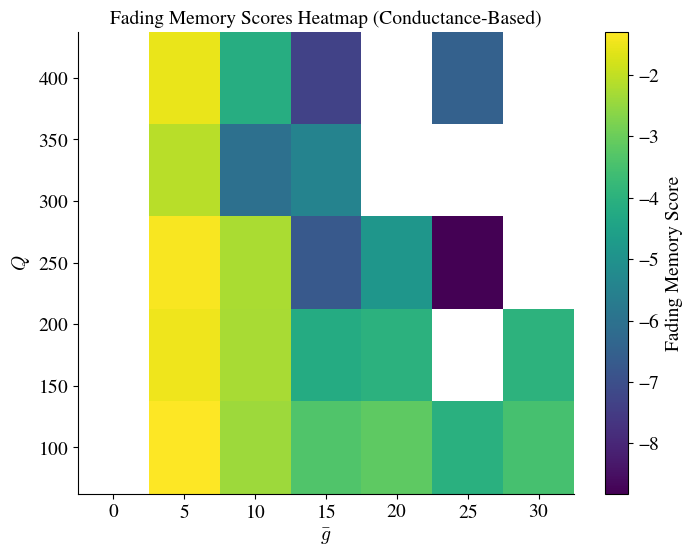

In [27]:
if "_current_" in path:
    plot_title = "Fading Memory Scores Heatmap (Current-Based)"
    save_name = "fading_memory_heatmap_current.pdf"
elif "_conductance_" in path:
    plot_title = "Fading Memory Scores Heatmap (Conductance-Based)"
    save_name = "fading_memory_heatmap_conductance.pdf"

# plot heatmap of fading memory scores with q on y-axis and gbar on x-axis
q_values = sorted(set([entry[0] for sublist in memory_scores for entry in sublist]))
gbar_values = sorted(set([entry[1] for sublist in memory_scores for entry in sublist]))
fading_memory_matrix = np.zeros((len(q_values), len(gbar_values)))
for gbar_idx in range(len(memory_scores)):
    for entry in memory_scores[gbar_idx]:
        q, gbar, fading_memory_score, rmse = entry
        q_idx = q_values.index(q)
        gbar_idx = gbar_values.index(gbar)
        fading_memory_matrix[q_idx, gbar_idx] = fading_memory_score
        
plt.figure(figsize=(8, 6))
clr = plt.pcolormesh(gbar_values, q_values, fading_memory_matrix, cmap="viridis")
plt.title(plot_title)
plt.xlabel(r"$\bar{g}$")
plt.ylabel(r"$Q$")
plt.colorbar(clr, label="Fading Memory Score")
plt.savefig(os.path.join(path, save_name), bbox_inches='tight')
plt.show()